In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from datetime import datetime

In [2]:
bitcoin_df_daily = pd.read_csv("BTC_history_daily.csv")
bitcoin_df_daily['time'] = pd.to_datetime(bitcoin_df_daily['time'])


In [3]:
# Select data for a specific year (e.g., 2015)
bitcoin2024 = bitcoin_df_daily[bitcoin_df_daily['time'].dt.year == 2024]

In [4]:
bitcoin2024

,time,high,low,open,volumefrom,volumeto,close,conversionType,conversionSymbol
3169,2024-01-01,44210.89,42187.32,42280.14,19499.59,8.398942e+08,44197.61,direct,NaN
3170,2024-01-02,45918.98,44181.86,44197.61,57443.36,2.596745e+09,44970.34,direct,NaN
3171,2024-01-03,45513.73,40214.67,44970.34,82056.19,3.533041e+09,42854.08,direct,NaN
3172,2024-01-04,44797.03,42657.44,42854.08,49538.94,2.167749e+09,44194.38,direct,NaN
3173,2024-01-05,44377.15,42508.08,44194.38,54169.30,2.368277e+09,44178.89,direct,NaN
...,...,...,...,...,...,...,...,...,...
3530,2024-12-27,97351.17,93270.34,95680.19,47149.30,4.479655e+09,94170.09,direct,NaN
3531,2024-12-28,95542.25,94008.53,94170.09,14159.69,1.339744e+09,95140.15,direct,NaN
3532,2024-12-29,95175.67,92850.44,95140.15,17921.90,1.684135e+09,93564.85,direct,NaN
3533,2024-12-30,94910.24,91310.52,93564.85,56846.06,5.287498e+09,92646.21,direct,NaN


In [5]:
# Create lagged features and technical indicators
def add_features(df):
    # Lagged features
    for lag in range(1, 6):  # 1 to 5 lags
        df[f'close_lag_{lag}'] = df['close'].shift(lag)

    # Drop rows with NaN values (created by shifting and rolling)
    df.dropna(inplace=True)

    return df

# Add features to your DataFrame
columns_to_drop = ['conversionType', 'conversionSymbol']
bitcoin2024 = bitcoin2024.drop(columns=columns_to_drop)
bitcoin_df_daily_f = add_features(bitcoin2024)
# Ensure datetime is set as index BEFORE splitting
bitcoin_df_daily_f = bitcoin_df_daily_f.set_index('time')  # Replace 'date' with your actual datetime column name if different

# Define features (X) and target (y)
features = ['close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_4', 'close_lag_5',]
target = 'close'


In [6]:
# Prepare data for modeling
test_size = 0.5
train, test = train_test_split(bitcoin_df_daily_f['close'], test_size=test_size, shuffle=False)

# 1. **SARIMAX model (no external variables)**
sarimax_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 60))  # Weekly seasonality
sarimax_fit = sarimax_model.fit()

# Forecast for the test set
sarimax_forecast = sarimax_fit.forecast(len(test))

# 2. **Linear Regression model (using previous 'close' values as a feature)**
train_lr, test_lr = train_test_split(bitcoin_df_daily_f, test_size=test_size, shuffle=False)

# Prepare training and test sets for Linear Regression
X_train_lr = train_lr[features]
y_train_lr = train_lr[target]
X_test_lr = test_lr[features]
y_test_lr = test_lr[target]

# Train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

# Make predictions with Linear Regression
lr_forecast = lr_model.predict(X_test_lr)

# 3. **Holt-Winters model (exponential smoothing)**
holt_winters_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=90)
holt_winters_fit = holt_winters_model.fit()

# Forecast for the test set
holt_winters_forecast = holt_winters_fit.forecast(len(test))


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: Valu

In [ ]:
print(sarimax_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                              close   No. Observations:                  180
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 60)   Log Likelihood               -1093.748
Date:                            Tue, 29 Apr 2025   AIC                           2197.496
Time:                                    16:26:12   BIC                           2211.392
Sample:                                01-06-2024   HQIC                          2203.139
                                     - 07-03-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3860      0.629     -0.614      0.539      -1.618       0.846
ma.L1          0.2680      0.636   

In [ ]:
print("Intercept:", lr_model.intercept_)
print("Coefficients:", lr_model.coef_)
print("Feature names:", X_train_lr.columns.tolist())


Intercept: 1395.6604990229098
Coefficients: [ 8.16126781e-01  1.73947192e-01  5.46186233e-02 -6.29120803e-04
 -6.58070643e-02]
Feature names: ['close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_4', 'close_lag_5']


In [ ]:
print(holt_winters_fit.params)


{'smoothing_level': np.float64(0.8889285714285714), 'smoothing_trend': np.float64(0.0001), 'smoothing_seasonal': np.float64(0.049365079365079376), 'damping_trend': nan, 'initial_level': np.float64(54578.519618518505), 'initial_trend': np.float64(269.29133703704156), 'initial_seasons': array([ 1658.39229383,  2503.61090494,  2746.32590494,  4823.5760716 ,
        2133.82940494,  3441.0280716 ,  2663.74568272,  -350.41176173,
       -3588.12381728, -1911.73809506, -4298.50903951, -3984.18348395,
       -6580.78809506, -4375.39626173, -4062.75620617, -2984.18637284,
       -3055.47898395, -1194.23948395, -1652.23698395, -3809.81498395,
       -3573.1839284 , -4286.5974284 , -4559.7729284 , -4833.3249284 ,
       -4064.48709506, -7266.89448395, -9615.47970617, -8791.55031728,
       -4977.8384284 , -4001.10303951, -3850.10370617, -4721.87759506,
       -5573.32326173, -6701.07753951, -4749.98870617, -6945.06809506,
       -6816.26937284, -6082.44470617, -4508.04826173, -5794.1954284 ,
    

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. **SARIMAX Evaluation**
sarimax_mse = mean_squared_error(test, sarimax_forecast)
sarimax_rmse = np.sqrt(sarimax_mse)
sarimax_mae = mean_absolute_error(test, sarimax_forecast)
sarimax_mape = mean_absolute_percentage_error(test, sarimax_forecast) * 100

# 2. **Linear Regression Evaluation**
lr_mse = mean_squared_error(y_test_lr, lr_forecast)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test_lr, lr_forecast)
lr_mape = mean_absolute_percentage_error(y_test_lr, lr_forecast) * 100

# 3. **Holt-Winters Evaluation**
holt_winters_mse = mean_squared_error(test, holt_winters_forecast)
holt_winters_rmse = np.sqrt(holt_winters_mse)
holt_winters_mae = mean_absolute_error(test, holt_winters_forecast)
holt_winters_mape = mean_absolute_percentage_error(test, holt_winters_forecast) * 100

# Create a DataFrame to compare models
model_comparison = pd.DataFrame({
    'Model': ['SARIMAX', 'Linear Regression', 'Holt-Winters'],
    'MSE': [sarimax_mse, lr_mse, holt_winters_mse],
    'RMSE': [sarimax_rmse, lr_rmse, holt_winters_rmse],
    'MAE': [sarimax_mae, lr_mae, holt_winters_mae],
    'MAPE': [sarimax_mape, lr_mape, holt_winters_mape]
})

print(model_comparison)


               Model           MSE          RMSE           MAE       MAPE
0            SARIMAX  1.401302e+08  11837.658577  10178.671734  15.510681
1  Linear Regression  4.294611e+06   2072.344220   1507.478415   2.074753
2       Holt-Winters  1.966164e+08  14021.996461  11746.914532  17.727542


In [ ]:
model_comparison

,Model,MSE,RMSE,MAE,MAPE
0,SARIMAX,1.401302e+08,11837.658577,10178.671734,15.510681
1,Linear Regression,4.294611e+06,2072.344220,1507.478415,2.074753
2,Holt-Winters,1.966164e+08,14021.996461,11746.914532,17.727542


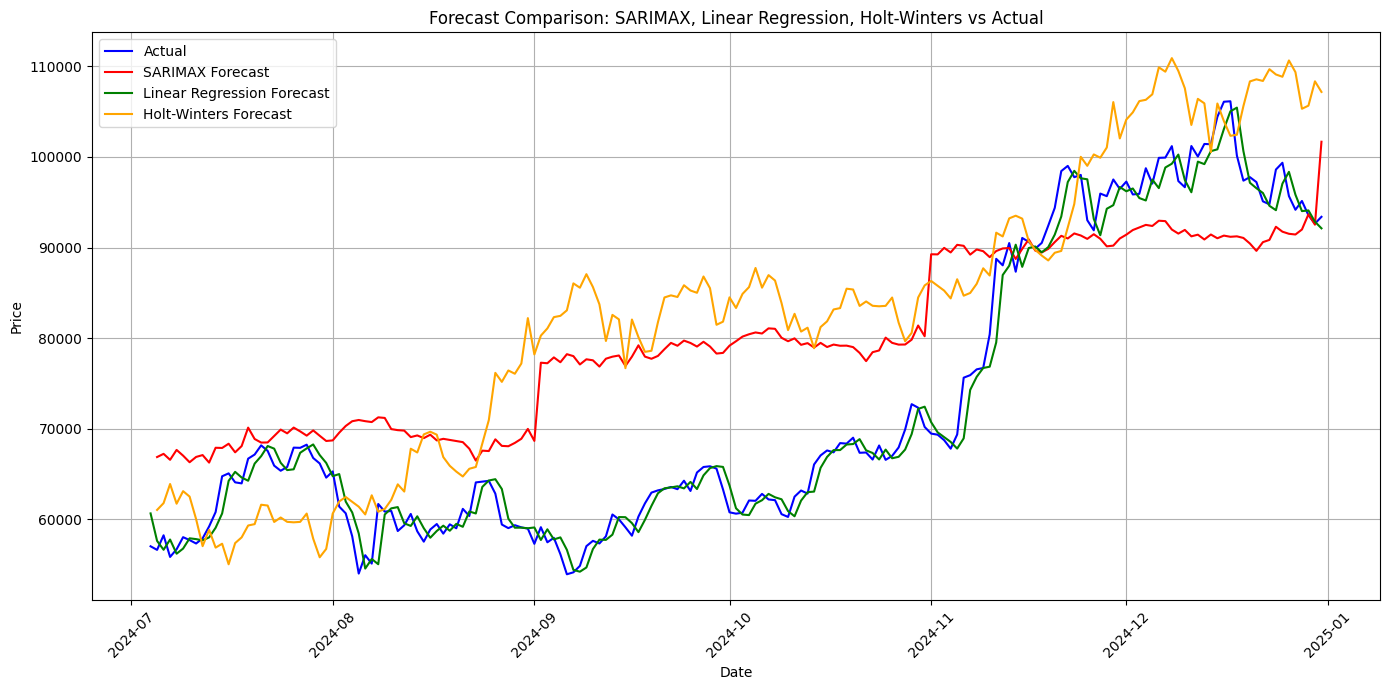

In [ ]:
import matplotlib.pyplot as plt

# Use the datetime index from test_lr for all forecasts
lr_index = test_lr.index
lr_index_cut = lr_index[1:]  # For SARIMAX and Holt-Winters, which are cut

# Ensure that the actual 'test' data uses the same datetime index as lr_index
test = test_lr['close']  # Assuming 'close' is the column you're working with in the test set

# Cut SARIMAX and Holt-Winters forecasts to align with the same index
sarimax_forecast_cut = sarimax_forecast[1:]
holt_winters_forecast_cut = holt_winters_forecast[1:]

# Plot the data
plt.figure(figsize=(14, 7))

# Plot actual values using datetime index
plt.plot(lr_index, test, label='Actual', color='blue')  # Use lr_index to match time

# Plot SARIMAX forecast using datetime index
plt.plot(lr_index_cut, sarimax_forecast_cut, label='SARIMAX Forecast', color='red')

# Plot Linear Regression forecast using datetime index
plt.plot(lr_index, lr_forecast, label='Linear Regression Forecast', color='green')

# Plot Holt-Winters forecast using datetime index
plt.plot(lr_index_cut, holt_winters_forecast_cut, label='Holt-Winters Forecast', color='orange')

# Formatting
plt.title('Forecast Comparison: SARIMAX, Linear Regression, Holt-Winters vs Actual')
plt.xlabel('Date')  # Automatically uses the datetime index for the x-axis
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


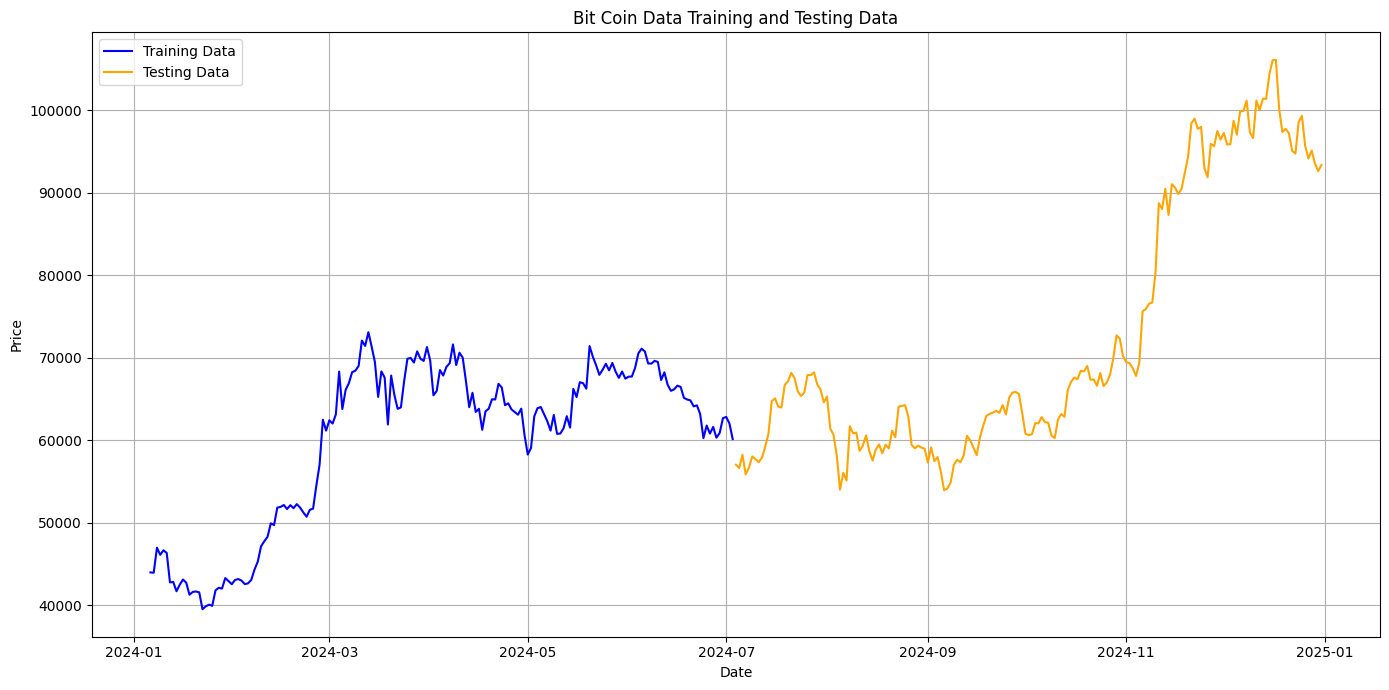

In [ ]:
import matplotlib.pyplot as plt

# Plot train and test data
plt.figure(figsize=(14, 7))

# Plot training data
plt.plot(train_lr.index, train_lr['close'], label='Training Data', color='blue')

# Plot testing data
plt.plot(test_lr.index, test_lr['close'], label='Testing Data', color='orange')

# Add titles and labels
plt.title('Bit Coin Data Training and Testing Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
train_lr

,high,low,open,volumefrom,volumeto,close,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5
time,,,,,,,,,,,
2024-01-06,44248.40,43444.90,44178.89,16352.13,7.170655e+08,43988.33,44178.89,44194.38,42854.08,44970.34,44197.61
2024-01-07,44496.47,43639.57,43988.33,20056.41,8.841547e+08,43950.84,43988.33,44178.89,44194.38,42854.08,44970.34
2024-01-08,47295.94,43209.80,43950.84,66057.64,3.000304e+09,46988.14,43950.84,43988.33,44178.89,44194.38,42854.08
2024-01-09,47923.17,44889.64,46988.14,66281.93,3.083633e+09,46123.00,46988.14,43950.84,43988.33,44178.89,44194.38
2024-01-10,47705.84,44326.32,46123.00,80226.64,3.677965e+09,46667.48,46123.00,46988.14,43950.84,43988.33,44178.89
...,...,...,...,...,...,...,...,...,...,...,...
2024-06-29,61129.31,60294.22,60324.30,9214.26,5.607110e+08,60905.30,60324.30,61630.10,60824.43,61796.56,60270.95
2024-06-30,62949.76,60637.50,60905.30,12626.61,7.787656e+08,62685.88,60905.30,60324.30,61630.10,60824.43,61796.56
2024-07-01,63800.98,62462.20,62685.88,25708.72,1.623105e+09,62841.27,62685.88,60905.30,60324.30,61630.10,60824.43
